In [1]:
import os
import numpy as np
import rasterio
from rasterio import plot
from rasterio.plot import show
import json
from natsort import natsorted
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from utils.image_pre_process import normalized_difference, stack_bands, stack_to_geotiff, get_bands, aoi_geojson_reader, aoi_geojson_reader, geojson_to_pixel_polygons, visualize_image_with_polygons
from example_change_detection import compute_change_distance

In [30]:
raster_path_1 = "data/sentinel2_20230812"
raster_path_2 = "data/sentinel2_20230902"

In [31]:
output_1 = 'data/processed/geotiff_old.tif'
output_2 = 'data/processed/geotiff_new.tif'
geojson_path = 'aoi.geojson'

In [32]:
bands_1 = get_bands(raster_path_1)
bands_2 = get_bands(raster_path_2)
# bands

{'B02': 'data/sentinel2_20230812/B02.tif', 'B03': 'data/sentinel2_20230812/B03.tif', 'B04': 'data/sentinel2_20230812/B04.tif'}
{'B02': 'data/sentinel2_20230902/B02.tif', 'B03': 'data/sentinel2_20230902/B03.tif', 'B04': 'data/sentinel2_20230902/B04.tif'}


In [33]:
list_of_bands = ['B02', 'B03', 'B04']
stack_1, raster_meta_1 = stack_bands(list_of_bands, bands_1)
stack_2, raster_meta_2 = stack_bands(list_of_bands, bands_2)

<open DatasetReader name='data/sentinel2_20230812/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 

<open DatasetReader name='data/sentinel2_20230902/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 



In [34]:
stack_to_geotiff(stack_1, raster_meta_1, output_1)
stack_to_geotiff(stack_2, raster_meta_1, output_2)

In [42]:
# stack = stack.astype(np.float32)
# demo algorythm
change_detection = compute_change_distance(stack_1.astype(np.float32), stack_2.astype(np.float32))

In [36]:
stack_to_geotiff(change_detection[0], raster_meta_1, 'data/processed/change.tif')
stack_to_geotiff(change_detection[1], raster_meta_1, 'data/processed/change_probability.tif')

In [25]:
raster_meta_1

{'nodata': 0.0,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 35S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32735"]]'),
 'transform': Affine(10.0, 0.0, 368430.0,
        0.0, -10.0, 8653770.0)}

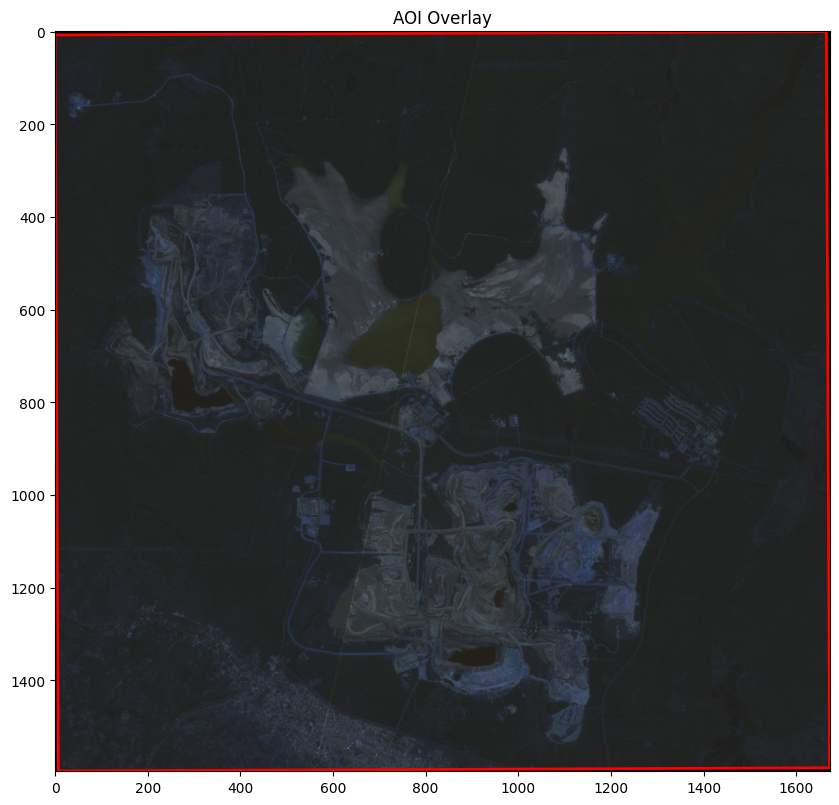

In [37]:
geojson_dict = aoi_geojson_reader(geojson_path)

pixel_polygons = geojson_to_pixel_polygons(geojson_dict, raster_meta_1)

visualize_image_with_polygons(stack_1, pixel_polygons, title="AOI Overlay")

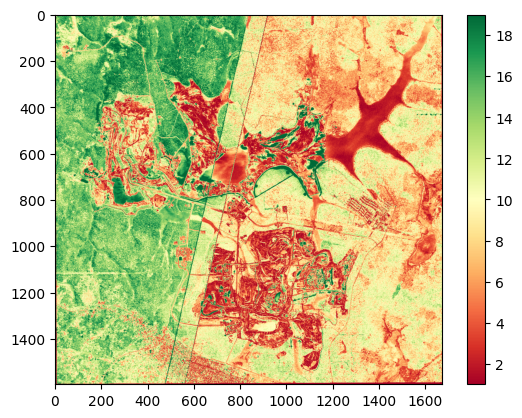

In [43]:
# change detection
plt.imshow(
    change_detection[0],
    cmap="RdYlGn",
    vmin=np.percentile(change_detection[0], 2),
    vmax=np.percentile(change_detection[0], 98)
)
plt.colorbar()

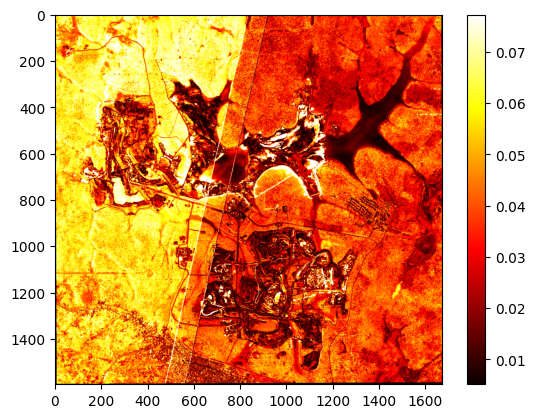

In [44]:
# change detection probability
plt.imshow(
    change_detection[1],
    cmap="hot",
    vmin=np.percentile(change_detection[1], 2),
    vmax=np.percentile(change_detection[1], 98)
)
plt.colorbar()